## Principal Component Analysis (PCA)

### 1. Loading data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data_path = "data/force/f_train.csv"
df = pd.read_csv(data_path, sep=",")
df.head()

,WELL,DEPTH_MD,GROUP,FORMATION,CALI,RSHA,RMED,RDEP,RHOB,GR,NPHI,PEF,DTC,SP,BS,ROP,DRHO,LITHOLOGY
0,15/9-15,1149.648,HORDALAND GP.,Utsira Fm.,17.482092,1.502680,1.502680,1.714187,2.063168,68.388885,0.541850,2.583011,134.226379,64.088852,17.5,23.217106,0.026319,65000
1,15/9-15,1149.800,HORDALAND GP.,Utsira Fm.,17.395611,1.505071,1.505071,1.716345,2.051136,71.170013,0.545401,2.506672,134.824799,65.575722,17.5,22.635521,0.019921,65000
2,15/9-15,1149.952,HORDALAND GP.,Utsira Fm.,17.364607,1.525162,1.525162,1.719259,2.041540,74.497498,0.548953,2.427594,135.037079,66.153511,17.5,21.852139,0.014932,65000
3,15/9-15,1150.104,HORDALAND GP.,Utsira Fm.,17.371887,1.541443,1.541443,1.723307,2.035698,76.098335,0.549356,2.401553,134.500336,64.918488,17.5,21.146048,0.009946,65000
4,15/9-15,1150.256,HORDALAND GP.,Utsira Fm.,17.370705,1.542996,1.542996,1.729302,2.029099,74.966675,0.543351,2.358777,132.162399,64.066925,17.5,20.553537,0.005706,65000


#### Display number of samples per well

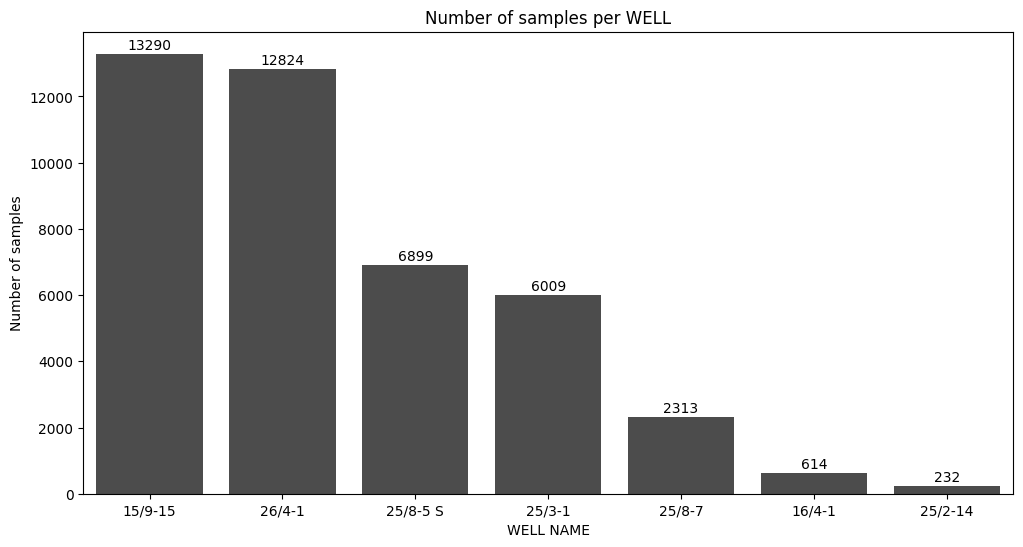

In [2]:
# Re-order column by descending values
well_counts = df.WELL.value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=well_counts.index, y=well_counts.values, color='black', alpha=0.7)
plt.title("Number of samples per WELL")
plt.xlabel("WELL NAME")
plt.ylabel("Number of samples")
plt.xticks(rotation=0)

# Add the value on top of each bar
for i, value in enumerate(well_counts.values):
    plt.text(i, value + 50, str(value), ha='center', va='bottom')

plt.show()

### 2. Label checking

In [3]:
# Save the Label 
DFLabel = df["LITHOLOGY"]

# Print the labels
print(f"There are {len(DFLabel)} types of lithology and it represents by the following codes: ", DFLabel.unique())

There are 42181 types of lithology and it represents by the following codes:  [65000 65030 30000 70000 99000 80000 70032 90000 74000]


### 3. Remove categories columns

In [4]:
# Drop categorical columns
pca_df = df.drop(['FORMATION', 'WELL', 'LITHOLOGY', 'GROUP'], axis=1)
display(pca_df.describe())
feature_names= pca_df.columns
print(f"Number of features: {len(feature_names)}, \nFeatures: {feature_names}")

,DEPTH_MD,CALI,RSHA,RMED,RDEP,RHOB,GR,NPHI,PEF,DTC,SP,BS,ROP,DRHO
count,42181.000000,42181.000000,42181.000000,42181.000000,42181.000000,42181.000000,42181.000000,42181.000000,42181.000000,42181.000000,42181.000000,42181.000000,42181.000000,42181.000000
mean,2426.485856,11.854190,2.762909,4.668206,4.693303,2.294450,71.477808,0.397697,5.823347,107.291108,48.998032,10.575671,22.657302,0.022613
std,721.828772,3.093467,11.856220,38.307630,55.783676,0.255689,32.498219,0.198608,5.856255,30.186918,138.137142,1.960491,17.986234,0.052292
min,761.041604,7.325138,0.005141,0.262247,0.264479,1.239131,6.024419,0.014492,1.074626,7.415132,-266.566284,8.500000,0.069603,-0.489363
25%,1863.174400,9.043562,0.841600,0.786579,0.686648,2.081967,54.144875,0.255004,3.288399,82.151833,38.700779,8.500000,8.395054,-0.011185
50%,2301.200000,12.342676,1.193334,1.280654,1.231505,2.312593,72.021515,0.361658,4.257130,99.381676,66.653862,12.250001,16.497211,0.007328
75%,3058.464000,13.364419,2.797484,3.580580,3.043633,2.532267,88.355316,0.500045,6.426693,134.931549,108.100883,12.250001,33.563400,0.044417
max,3907.120000,25.717396,779.958923,1988.616333,1999.877808,2.894546,1076.963867,0.999570,288.103638,205.208664,273.084320,17.500000,236.408310,0.308971


Number of features: 14, 
Features: Index(['DEPTH_MD', 'CALI', 'RSHA', 'RMED', 'RDEP', 'RHOB', 'GR', 'NPHI', 'PEF',
       'DTC', 'SP', 'BS', 'ROP', 'DRHO'],
      dtype='object')


### 4. Standardization

In [5]:
from sklearn.preprocessing import StandardScaler

#Instantiate
scaler = StandardScaler() 
# Scale data
pca_df = scaler.fit_transform(pca_df)

print("DF Type:", type(pca_df))
print("DF Shape:", pca_df.shape)
print("The first sample of normalized data: \n", pca_df[:1])

DF Type: <class 'numpy.ndarray'>
DF Shape: (42181, 14)
The first sample of normalized data: 
 [[-1.76891396  1.81930799 -0.10629388 -0.08263531 -0.05340543 -0.90455789
  -0.0950501   0.72582432 -0.55331858  0.89229349  0.1092465   3.53197859
   0.03112436  0.07087746]]


### 5. PCA with `n_components = 2`

The eigenvalues: [5.03954825 1.54230647]
Some first samples of the transformed data: 
 [[ 3.61813352  0.02590144]
 [ 3.62220052 -0.06091206]
 [ 3.62625408 -0.13844093]
 [ 3.61638462 -0.2216019 ]
 [ 3.56948422 -0.2919642 ]]


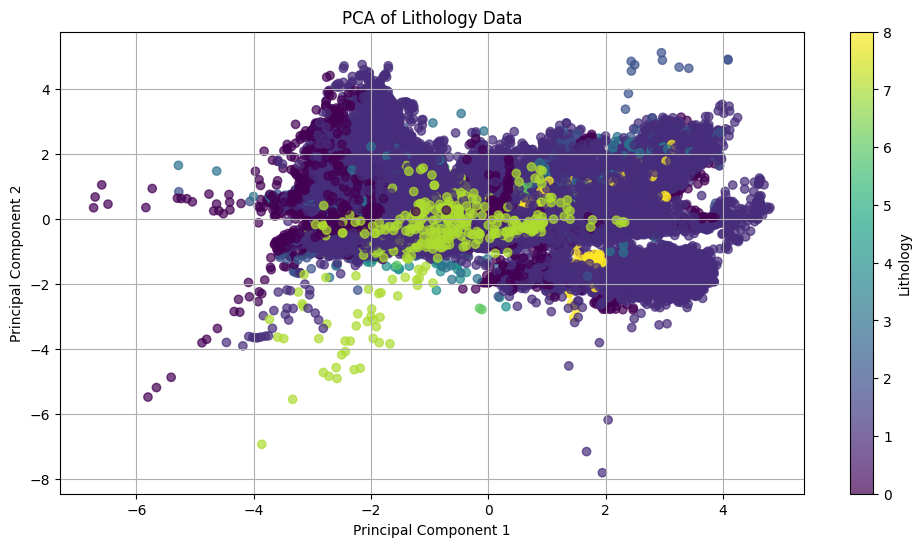

In [17]:
from sklearn.decomposition import PCA

PCA_2components = PCA(n_components=2)

# Project the original data into the PCA space
Result = PCA_2components.fit_transform(pca_df)

print("The eigenvalues:", PCA_2components.explained_variance_)

# Print the values of the first component 
print("Some first samples of the transformed data: \n", Result[:5,:])

# Plot the PCA results
plt.figure(figsize=(12, 6))
plt.scatter(Result[:, 0], Result[:, 1], c=DFLabel.astype('category').cat.codes, cmap='viridis', alpha=.7)
plt.title("PCA of Lithology Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label='Lithology')
plt.grid(True)
plt.show()

[5.03954825 6.58185472]
[0.3599592  0.11016214]


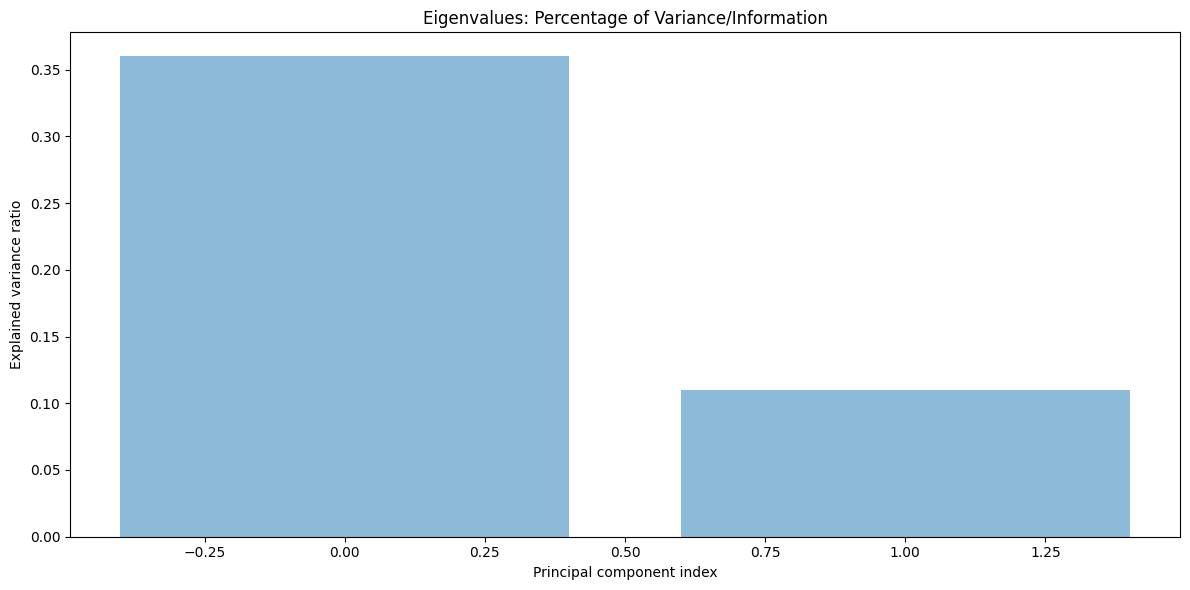

In [7]:
fig_2c_pca=plt.figure()
fig_2c_pca.set_size_inches(12, 6)
ACCUM_eigenvalues = np.cumsum(PCA_2components.explained_variance_)
print(ACCUM_eigenvalues)
print(PCA_2components.explained_variance_ratio_)
plt.bar(range(0,len(PCA_2components.explained_variance_ratio_)), PCA_2components.explained_variance_ratio_, 
        alpha=0.5, align='center', label='Individual Explained Variances')
# plt.step(range(0,len(ACCUM_eigenvalues)), ACCUM_eigenvalues, where='mid',label='Cumulative Explained Variances')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.title("Eigenvalues: Percentage of Variance/Information")
#plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [8]:
shape = PCA_2components.components_.shape[0]

most_important = [np.abs(PCA_2components.components_[i]).argmax() for i in range(shape)]
most_important_names = [feature_names[most_important[i]] for i in range(shape)]

# Build a doctionary of the imprtant features by PC
MyDic = {'PC{}'.format(i): most_important_names[i] for i in range(shape)}

# build the dataframe
Important_DF = pd.DataFrame(MyDic.items())
print(Important_DF)

     0     1
0  PC0   DTC
1  PC1  DRHO


### 6. PCA with `n_components = 3`

In [9]:
PCA_3components = PCA(n_components=3)

# Project the original data into the PCA space
Result = PCA_3components.fit_transform(pca_df)

print("The eigenvalues:", PCA_3components.explained_variance_)

# Print the values of the first component 
print("Some first samples of the transformed data: \n", Result[:5,:])

The eigenvalues: [5.03954825 1.54230647 1.31837205]
Some first samples of the transformed data: 
 [[ 3.61813352  0.02590144 -0.98127382]
 [ 3.62220052 -0.06091206 -0.91790231]
 [ 3.62625408 -0.13844093 -0.85023072]
 [ 3.61638462 -0.2216019  -0.83094022]
 [ 3.56948422 -0.2919642  -0.88199687]]


[5.03954825 6.58185472 7.90022677]
[0.3599592  0.11016214 0.0941672 ]


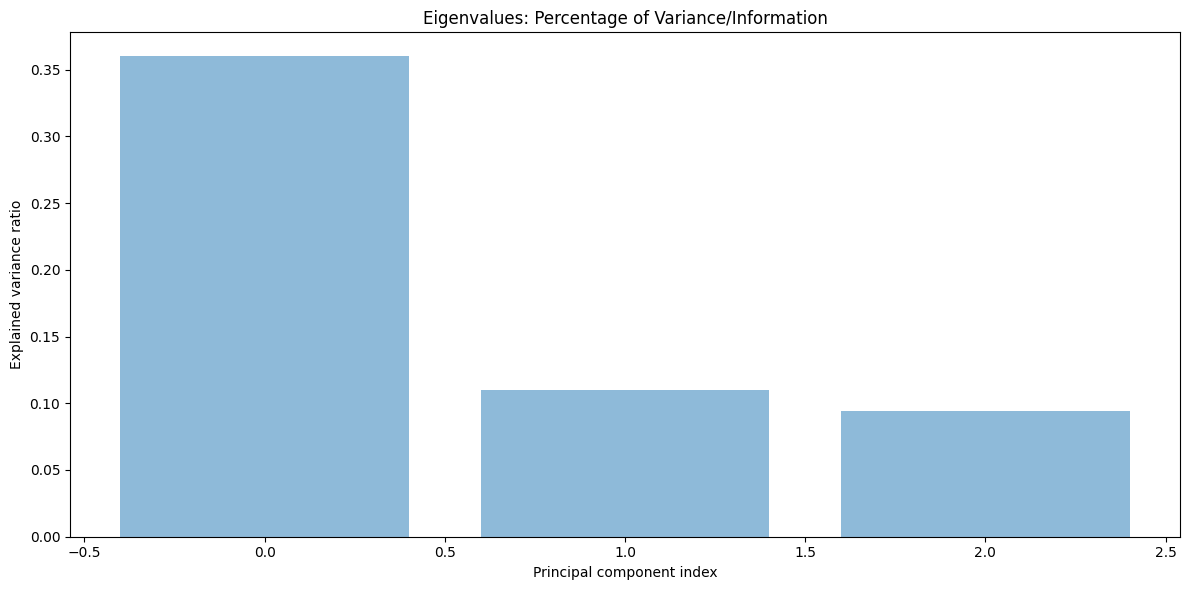

In [10]:
fig_3c_pca=plt.figure()
fig_3c_pca.set_size_inches(12, 6)
ACCUM_eigenvalues = np.cumsum(PCA_3components.explained_variance_)
print(ACCUM_eigenvalues)
print(PCA_3components.explained_variance_ratio_)
plt.bar(range(0,len(PCA_3components.explained_variance_ratio_)), PCA_3components.explained_variance_ratio_, 
        alpha=0.5, align='center', label='Individual Explained Variances')
# plt.step(range(0,len(ACCUM_eigenvalues)), ACCUM_eigenvalues, where='mid',label='Cumulative Explained Variances')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.title("Eigenvalues: Percentage of Variance/Information")
#plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [11]:
MyCov=np.cov(Result.T)

# The variance here (on the diagonal) will match the eigenvalues
print("Covar of the PC PCA Matrix: \n", MyCov)
print("\nThe relative eigenvalues are:",PCA_3components.explained_variance_ratio_)
print("\nThe actual eigenvalues are:", PCA_3components.explained_variance_)
EVects=PCA_3components.components_
print("\nThe eigenvectors are:\n",EVects)
print("\nEVects Type:", type(EVects))
print("\nThe shape of the eigenvector matrix is\n", EVects.shape)
print("\nDF Shape:", pca_df.shape)
# Proof to transform origial data to eigenbasis
# Using the eigenvectors matrix.
print(EVects.T[:5])
#  (15, 4) @ (4, 3)
Transf=pca_df@EVects.T
print("\nProof that the transformed data is the EVects @ Data\n",Transf[:5])

Covar of the PC PCA Matrix: 
 [[ 5.03954825e+00 -3.49417560e-16 -4.43036367e-17]
 [-3.49417560e-16  1.54230647e+00  5.70767289e-16]
 [-4.43036367e-17  5.70767289e-16  1.31837205e+00]]

The relative eigenvalues are: [0.3599592  0.11016214 0.0941672 ]

The actual eigenvalues are: [5.03954825 1.54230647 1.31837205]

The eigenvectors are:
 [[-0.39928307  0.35316674 -0.081651   -0.04884704 -0.0383451  -0.36738089
   0.03712511  0.36534495  0.03396736  0.40348874 -0.27717624  0.37851063
   0.2090576   0.08797792]
 [ 0.13887759  0.1367512   0.01921908 -0.08954201 -0.0797751  -0.13022733
  -0.01816217 -0.15352604 -0.0403907   0.12134768  0.54361026 -0.0690827
   0.38816963  0.66263473]
 [ 0.05696821 -0.28693828 -0.0007837   0.21103501  0.23606409  0.03709996
   0.6811409   0.28138354 -0.38047068  0.12766453 -0.06802606 -0.21571719
   0.23555324  0.04415212]]

EVects Type: <class 'numpy.ndarray'>

The shape of the eigenvector matrix is
 (3, 14)

DF Shape: (42181, 14)
[[-0.39928307  0.13887759  

In [16]:
import plotly.express as px

fig = px.scatter_3d(
    x=Result[:, 2],
    y=Result[:, 1],
    z=Result[:, 0],
    color=DFLabel.astype(str),
    labels={'x': 'PC2', 'y': 'PC1', 'z': 'PC0'},
    title='3D PCA',
    width=1000,
    height=600
)
fig.update_traces(marker=dict(size=3, opacity=0.5))

fig.show()


In [14]:
shape= PCA_3components.components_.shape[0]

most_important = [np.abs(PCA_3components.components_[i]).argmax() for i in range(shape)]
most_important_names = [feature_names[most_important[i]] for i in range(shape)]

# Build a doctionary of the imprtant features by PC
MyDic = {'PC{}'.format(i): most_important_names[i] for i in range(shape)}

# build the dataframe
Important_DF = pd.DataFrame(MyDic.items())
print(Important_DF)

     0     1
0  PC0   DTC
1  PC1  DRHO
2  PC2    GR


### 7. Accumulated 95% PCA data

The eigenvalues: [5.03954825 1.54230647 1.31837205 1.16990519 1.07509273 0.96384957
 0.80827721 0.68653132 0.46607972 0.35470801 0.22866435 0.14914049
 0.11263696 0.08521959]
Accumulated explained variance ratio: [0.3599592  0.47012133 0.56428853 0.64785121 0.72464173 0.79348649
 0.85121921 0.900256   0.93354662 0.9588823  0.97521509 0.98586772
 0.99391303 1.        ]


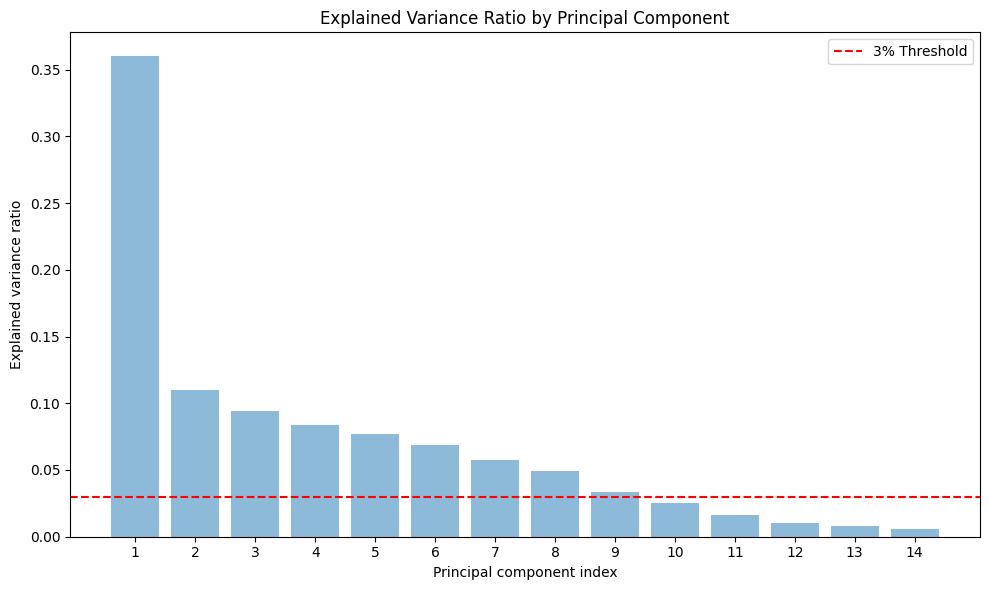

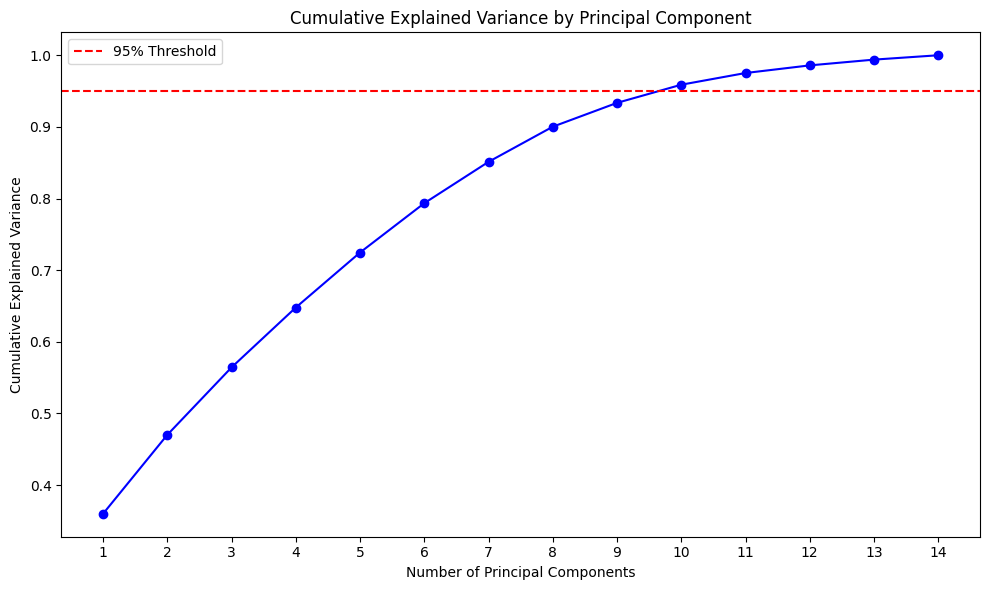

In [15]:
PCA_all_components = PCA(n_components=14)

# Project the original data into the PCA space
Result = PCA_all_components.fit_transform(pca_df)

print("The eigenvalues:", PCA_all_components.explained_variance_)

# Calculate accumulated explained_variance_ratio_
accumulated_variance = np.cumsum(PCA_all_components.explained_variance_ratio_)
print("Accumulated explained variance ratio:", accumulated_variance)

# Barplot of explained variance ratio
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(PCA_all_components.explained_variance_ratio_) + 1), PCA_all_components.explained_variance_ratio_, alpha=0.5, align='center')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.title('Explained Variance Ratio by Principal Component')
plt.xticks(range(1, len(PCA_all_components.explained_variance_ratio_) + 1))
plt.axhline(y=0.03, color='r', linestyle='--', label='3% Threshold')
plt.legend()
plt.tight_layout()
plt.show()

# Plot the cumulative explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(accumulated_variance) + 1), accumulated_variance, marker='o', linestyle='-', color='b')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
plt.ylabel('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.title('Cumulative Explained Variance by Principal Component')
plt.xticks(range(1, len(accumulated_variance) + 1))
plt.legend()
plt.tight_layout()
plt.show()

8 features cover up to 90% the variance of the data and 10 out of 14 features cancover 95% of the data